Image loaded successfully! Creating a synthetic target image for registration...
Alignment complete! Generating inline plots...


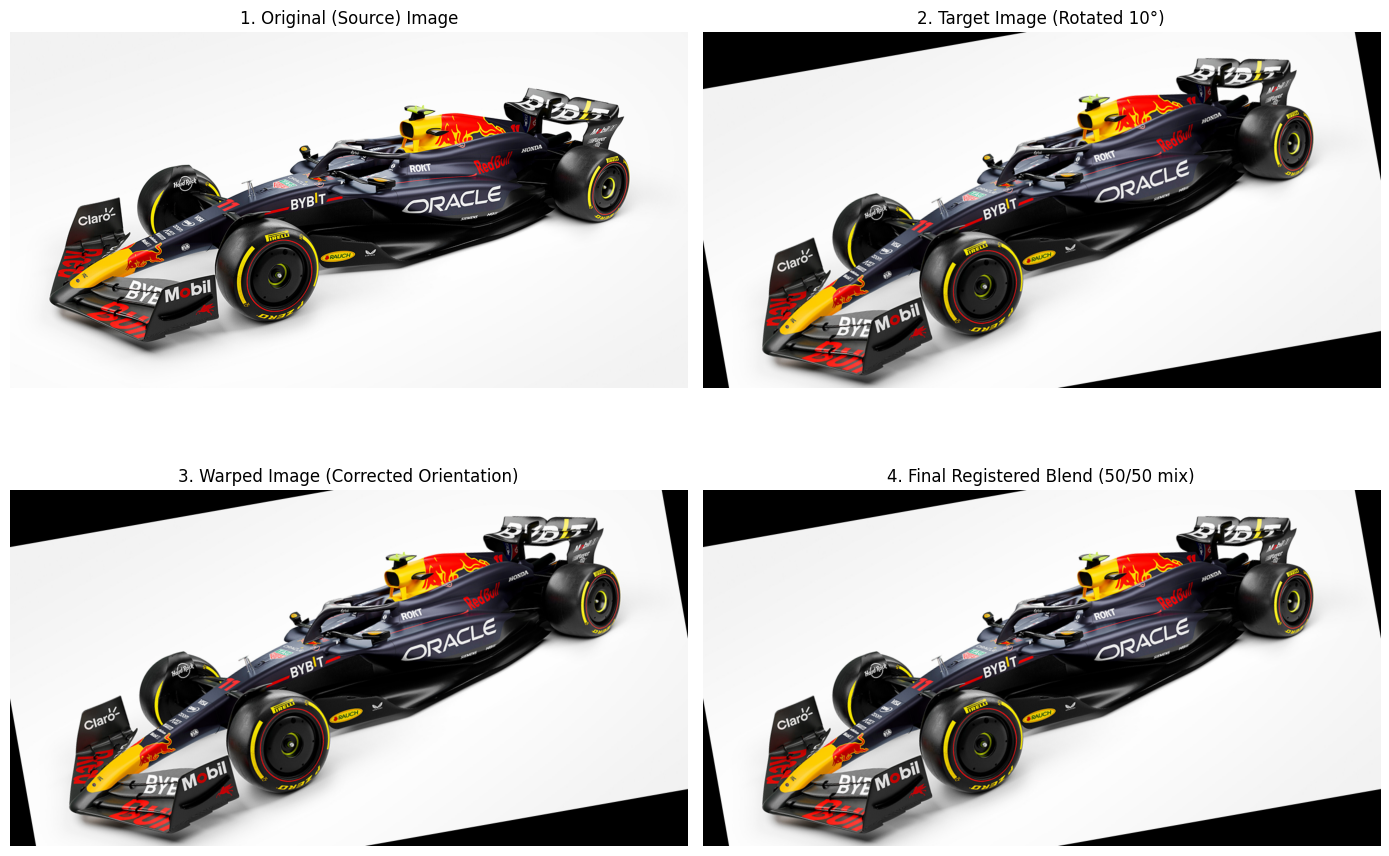

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the Custom Functions from Chapter 5 ---

def extract_SIFT(img):
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(img, None)
    return kp, des

def match_SIFT(descriptor_source, descriptor_target):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(descriptor_source, descriptor_target, k=2)
    
    # Initialize an empty array with 2 columns for indices
    pos = np.empty((0, 2), dtype=int)
    
    # Lowe's ratio test
    for m, n in matches:
        if m.distance <= 0.8 * n.distance:
            temp = np.array([m.queryIdx, m.trainIdx])
            pos = np.vstack((pos, temp))
    return pos

def estimate_affine(pts_s, pts_t):
    src_pts = pts_s.T.astype(np.float32)
    dst_pts = pts_t.T.astype(np.float32)
    M, _ = cv2.estimateAffine2D(src_pts, dst_pts)
    if M is not None:
        return M[:, :2], M[:, 2:]
    return np.eye(2), np.zeros((2, 1))

def residual_lengths(A, t, pts_s, pts_t):
    pred_t = np.dot(A, pts_s) + t
    residuals = np.linalg.norm(pts_t - pred_t, axis=0)
    return residuals

def ransac_fit(pts_s, pts_t, ITER_NUM=2000, threshold=1.0, K=3):
    inliers_num = 0
    A, t, inliers = None, None, None
    
    for i in range(ITER_NUM):
        idx = np.random.randint(0, pts_s.shape[1], K)
        A_tmp, t_tmp = estimate_affine(pts_s[:, idx], pts_t[:, idx])
        
        residual = residual_lengths(A_tmp, t_tmp, pts_s, pts_t)
        inliers_tmp = np.where(residual < threshold)
        inliers_num_tmp = len(inliers_tmp[0])
        
        if inliers_num_tmp > inliers_num:
            inliers_num = inliers_num_tmp
            inliers = inliers_tmp
            A = A_tmp
            t = t_tmp
            
    return A, t, inliers

def affine_matrix(keypoint_source, keypoint_target, pos):
    s = np.array([keypoint_source[idx].pt for idx in pos[:, 0]]).T
    t = np.array([keypoint_target[idx].pt for idx in pos[:, 1]]).T
    
    _, _, inliers = ransac_fit(s, t)
    
    if inliers is None:
        return np.hstack((np.eye(2), np.zeros((2, 1))))
        
    s_inliers = s[:, inliers[0]]
    t_inliers = t[:, inliers[0]]
    A, t_vec = estimate_affine(s_inliers, t_inliers)
    
    M = np.hstack((A, t_vec))
    return M

# --- 2. Main Single-Image Pipeline ---

# Load your single existing image
path_source = "f1_rgb_back.png"
img_source = cv2.imread(path_source)

if img_source is None:
    print(f"Error: Could not load your image from {path_source}. Please verify the path.")
else:
    print("Image loaded successfully! Creating a synthetic target image for registration...")
    
    # Get image dimensions
    rows, cols, _ = img_source.shape
    
    # Create a synthetic target image by rotating the source image slightly (e.g., 10 degrees)
    rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), 10, 1.0)
    img_target = cv2.warpAffine(img_source, rotation_matrix, (cols, rows))
    
    # Run the feature pipeline
    keypoint_source, descriptor_source = extract_SIFT(img_source)
    keypoint_target, descriptor_target = extract_SIFT(img_target)

    # Match descriptors
    pos = match_SIFT(descriptor_source, descriptor_target)

    if len(pos) < 3:
        print("Error: Not enough matching points found to compute the registration.")
    else:
        # Calculate alignment transformation matrix
        H = affine_matrix(keypoint_source, keypoint_target, pos)

        # Warp the source image to match the target's orientation
        warp = cv2.warpAffine(img_source, H, (cols, rows))

        # Blend both images at 50% opacity to see if they line up
        merge = np.uint8(img_target * 0.5 + warp * 0.5)

        print("Alignment complete! Generating inline plots...")

        # --- 3. Inline Visualization for All 4 Images ---
        # Convert all matrices from BGR (OpenCV) to RGB (Matplotlib) format
        img_source_rgb = cv2.cvtColor(img_source, cv2.COLOR_BGR2RGB)
        img_target_rgb = cv2.cvtColor(img_target, cv2.COLOR_BGR2RGB)
        warp_rgb = cv2.cvtColor(warp, cv2.COLOR_BGR2RGB)
        merge_rgb = cv2.cvtColor(merge, cv2.COLOR_BGR2RGB)

        # Create a 2x2 plotting grid
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Image 1: Original Image
        axes[0, 0].imshow(img_source_rgb)
        axes[0, 0].set_title("1. Original (Source) Image")
        axes[0, 0].axis('off')

        # Image 2: Target Image
        axes[0, 1].imshow(img_target_rgb)
        axes[0, 1].set_title("2. Target Image (Rotated 10°)")
        axes[0, 1].axis('off')

        # Image 3: Warped Image (Aligned by your custom code)
        axes[1, 0].imshow(warp_rgb)
        axes[1, 0].set_title("3. Warped Image (Corrected Orientation)")
        axes[1, 0].axis('off')

        # Image 4: Blended Result
        axes[1, 1].imshow(merge_rgb)
        axes[1, 1].set_title("4. Final Registered Blend (50/50 mix)")
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()